---
# Exemple d'analyse de la base de données sur le naufrage du Titanic
### Auteur: Pierre Gravel <pierre.gravel@iid.ulaval.ca>
### Institut intelligence et données (IID), Québec, Canada
### License: BSD
---

<p>&nbsp;</p>
<div align="center">
    <img src= "images/R2.jpg"  width="500" />
    <div>
    <font size="1.5">Image Source: https://www.tonybates.ca/2014/01/28/is-athabasca-university-moving-away-from-tutoring//</font>
    </div>
</div>
<p>&nbsp;</p>

Dans ce tutoriel, nous allons voir un exemple complet de classification appliqué à des données réelles. Nous allons utiliser les données de la compétition Kaggle sur le [Titanic](https://www.kaggle.com/competitions/titanic/overview). C'est d'ailleurs la plus [populaire](https://dataaspirant.com/most-popular-kaggle-competition-solutions/) sur ce site. C'est un des exemples les plus utilisés en apprentissage automatique (AA) pour les raisons suivantes
<ul>
<li>la plupart des gens connaissent l'histoire du naufrage du Titanic,</li>
<li>les données utilisées sont réelles,</li>
<li>il n'y a que deux classes; les gens qui ont survécu ou non,</li>
<li>les données sont numériques et catégoriques,</li>
<li>les données doivent être nettoyées,</li>
<li>les données doivent être prétraitées et balancées pour les deux classes,</li>
<li>enfin, l'AA permet de retrouver plusieurs des conclusions obtenues par les commissions d'enquêtes sur la catastrophe!</li>
</ul>    

Le fait que les classes soient clairement séparées est important. Les gens sont soit des survivants, soit des victimes. Il n'y a personne entre les deux états. Ce n'est pas le cas avec une maladie telle que le diabète; il y a des gens sans diabète, des gens diabétiques et des gens dont la santé évolue vers le diabète. Ces derniers ne sont ni sains, ni pleinement diabétiques.  

Nous allons effectuer et expliquer les étapes suivantes :
- le nettoyage des données ;
- l'entraînement et l'optimisation de différents classificateurs et sélection du meilleur d'entre eux ;
- l'utilisation de la méthode d'interprétabilité SHAP (*SHapley Additive exPlanations*) pour mieux comprendre les prédictions et voir comment elles dépendent des caractéristiques des passagers (âge, sexe, etc.).


## Table des matières
1. Lecture de la base de données
   1. Informations sur la base de données
   2. Nettoyage de la base de données
2. Classification binaire des données des passagers
    1. Définition d'un pipeline de traitement des données
    2. Entraînement et optimisation d'un classificateur
    3. Faire une prédiction pour un nouveau passager
3. Interprétabilité des résultats de classification de survie au naufrage
    1. Préparation des données pour cette partie
    2. Calcul des valeurs SHAP pour le modèle optimal
    3. Faire une prédiction pour un nouveau passager
    4. Comment les caractéristiques individuelles influencent-elles la probabilité de survie?
5. Conclusion

#### Importation des librairies utilisées.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import shap
import umap
import math

import sklearn
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, StratifiedShuffleSplit, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import DBSCAN
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.neighbors import LocalOutlierFactor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, cross_val_score

from xgboost import XGBClassifier, XGBRegressor

from tqdm import tqdm

import optuna
from scipy.stats import randint, uniform, loguniform

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from warnings import filterwarnings
filterwarnings('ignore')

%matplotlib inline
import seaborn as sns
sns.set(color_codes=True)
pd.options.display.float_format = "{:.2f}".format

import random
import os

# Pour la reproductibilité globale
SEED = 41

np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

---
## Partie I: Lecture de la base de données
---

### Informations sur la base de données.

<p>&nbsp;</p>
<div align="center">
    <img src= "images/titanic-passenger-list-jon-neidert.jpg"  width="400" />
    <div>
    <font size="1.5">Image Source:https://fineartamerica.com/featured/titanic-passenger-list-jon-neidert.html/</font>
    </div>
</div>
<p>&nbsp;</p>
 
La base de données [Titanic](https://www.kaggle.com/competitions/titanic/data) 
contient 10 variables continues et catégoriques:

<ul>
<li><b>Survived</b>: indique si le passager a survécu (1) ou non (0),</li>
<li><b>Pclass</b>: classe des billets (1, 2, 3),</li>
<li><b>Sex</b>: sexe des passagers; femmes (0), hommes (1),</li>
<li><b>Age</b>: âge des passagers,</li>
<li><b>SibSp</b>: nombre de frères et sœurs ou d'époux d'une personne à bord,</li>
<li><b>Parch</b>: nombre de parents ou d'enfants avec lesquels chaque passager voyage,</li>
<li><b>Ticket</b>: numéro du billet d'embarquement,</li>
<li><b>Fare</b>: prix du billet,</li>
<li><b>Cabin</b>: numéro de la cabine,</li>
<li><b>Embarked</b>: port d'embarquement (Cherbourg, Queenstown, Southampton).</li>
</ul>    
    
#### Lecture des données

Les données sont déjà séparées en ensembles d'entraînement et de test.

In [2]:
df_train = pd.read_csv("fichiers/titanic_train.csv")
df_test = pd.read_csv("fichiers/titanic_test.csv")

#### Affichage des premières lignes du jeu de données d'entraînement

Ces données sont extraites du registre des voyageurs dont une page apparaît ci-dessus.

In [3]:
df_train.head()

,Unnamed: 0,index,Pclass,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.34,S
1,1,1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.55,S
2,2,2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.55,S
3,3,3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.55,S
4,4,4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.55,S


On voit qu'il y a des données catégorielles ainsi que des données numériques couvrant plusieurs ordres de grandeur.

#### Élimination des colonnes inutiles.

In [4]:
df_train = df_train.drop(['Unnamed: 0', 'index'], axis=1)
df_test = df_test.drop(['Unnamed: 0', 'index'], axis=1)

Nouvel affichage des premières lignes du jeu de données d'entraînement

In [5]:
df_train.head()

,Pclass,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.34,S
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.55,S
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.55,S
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.55,S
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.55,S


### Nettoyage de la base de données

#### Élimination des doublons

<p>&nbsp;</p>
<div align="center">
    <img src= "images/alice.jpeg"  width="300" />
</div>
<p>&nbsp;</p>

Les doublons désignent des données répétées. Cela se produit lorsque des bases de données sont assemblées à partir d'autres bases de données qui peuvent se recouper. Il faut éliminer ces informations redondantes. Lorsqu'elles sont doublées au sein d'un même ensemble, on élimine toutes les copies sauf une.

Lorsque des données sont doublées entre les ensembles « train » et « test », on parle de fuite de données (*data leaking*). Il est recommandé d'éliminer les deux copies dans les deux ensembles afin de conserver les distributions statistiques originales. En effet, supprimer trop de copies doublées de l'un des ensembles biaiserait statistiquement celui-ci par rapport à l'autre, et *vice versa*. 

In [6]:
# Nombre de lignes avant suppression
n_train_avant = df_train.shape[0]
n_test_avant = df_test.shape[0]

# Éliminations des doublons dans chaque ensemble
df_train = df_train.drop_duplicates()
df_test  = df_test.drop_duplicates()

# Identification des lignes communes entre les deux ensembles. Ce sont aussi des doublons.
common = pd.merge(df_train, df_test, how="inner")

# Suppression des lignes communes entre les deux ensembles.
df_train = df_train.merge(common, how="left", indicator=True)
df_train = df_train[df_train["_merge"] == "left_only"].drop(columns="_merge")

df_test = df_test.merge(common, how="left", indicator=True)
df_test = df_test[df_test["_merge"] == "left_only"].drop(columns="_merge")

# Nombre de lignes après suppression
n_train_apres = df_train.shape[0]
n_test_apres = df_test.shape[0]

# Calcul du nombre et du pourcentage de doublons
n_doublons = n_train_avant - n_train_apres
percentage = 100 * n_doublons / n_train_avant    
print(f"Doublons supprimés train : {n_doublons} lignes ({percentage:.1f} %)")

n_doublons = n_test_avant - n_test_apres
percentage = 100 * n_doublons / n_test_avant    
print(f"Doublons supprimés test : {n_doublons} lignes ({percentage:.1f} %)")

Doublons supprimés train : 0 lignes (0.0 %)
Doublons supprimés test : 0 lignes (0.0 %)


Il n'y avait aucun doublon dans les jeux de données. On peut donc éliminer les variables *Name* et *Ticket* qui sont désormais inutiles. Il aurait été risqué de les supprimer avant d'éliminer les doublons, car il est possible que, mis à part leur nom, des passagers aient les mêmes valeurs pour les variables *Pclass*, *Survived*, *Sex*, *Age*, *SibSp*, *Parch*, *Fare* et *Embarked*. Ce risque est d'autant plus élevé que le registre des voyageurs comporte des valeurs manquantes.

In [7]:
df_train = df_train.drop(['Name', 'Ticket'], axis=1)
df_test = df_test.drop(['Name', 'Ticket'], axis=1)

Nouvel affichage des premières lignes du jeu de données d'entraînement

In [8]:
df_train.head()

,Pclass,Survived,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,1,female,29.00,0,0,211.34,S
1,1,1,male,0.92,1,2,151.55,S
2,1,0,female,2.00,1,2,151.55,S
3,1,0,male,30.00,1,2,151.55,S
4,1,0,female,25.00,1,2,151.55,S


#### Séparation des colonnes contenant les caractéristiques X (*features*) permettant de prédire la réponse Y (*target*).

Ce sont les mêmes dans les ensembles d'entraînement et de test.

In [9]:
Xcol = df_train.drop(['Survived'], axis=1).columns.to_list()
Ycol = 'Survived'

Définissons une fonction pour afficher les histogrammes des caractéristiques X.

In [10]:
def affiche_histogrammes(Xcol, df, bins=None):
    ncols = 2
    nrows = math.ceil(len(Xcol) / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 2 * nrows))
    axes = axes.flatten()

    for i, name in enumerate(Xcol):
        if bins is None:
            sns.histplot(df, x=name, hue="Survived", multiple="stack", ax=axes[i])
        else:
            sns.histplot(df, x=name, hue="Survived", multiple="stack", ax=axes[i], bins=bins)
        axes[i].set_title(name)

    # Supprimer les axes inutilisés
    for j in range(len(Xcol), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

Affichage de l'histogramme original de chaque variable dans l'ensemble d'**entraînement**.

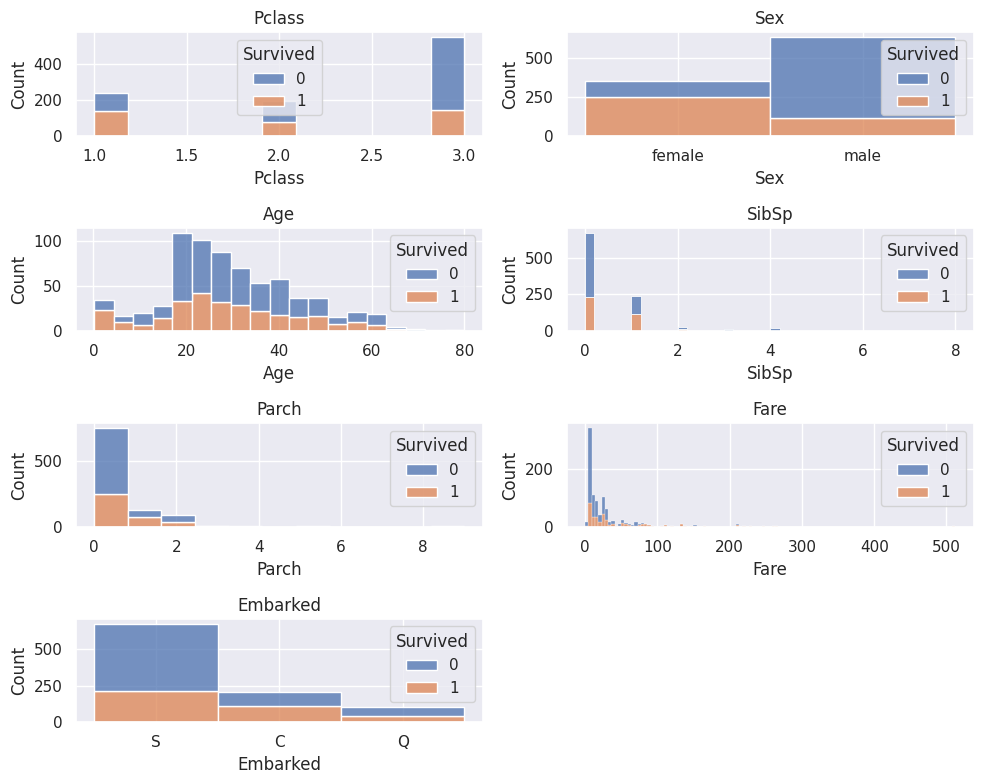

In [11]:
affiche_histogrammes(Xcol, df_train, bins=None)

Affichage de l'histogramme original de chaque variable dans l'ensemble de **test**.

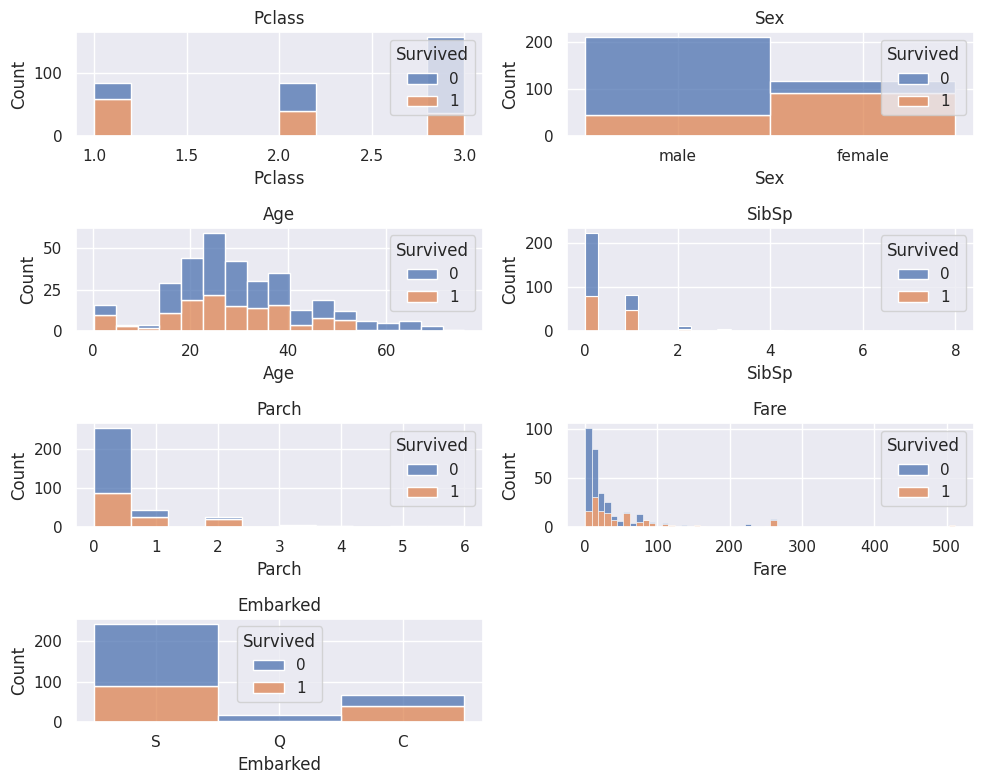

In [12]:
affiche_histogrammes(Xcol, df_test, bins=None)

On constate que les deux jeux de données présentent des distributions légèrement différentes pour les mêmes variables. Nous les considérerons toutefois comme similaires. 

#### Détection des valeurs manquantes

<p>&nbsp;</p>
<div align="center">
    <img src= "images/missing-data-illustration.jpeg"  width="300" />
</div>
<p>&nbsp;</p>

Les valeurs manquantes dans les bases de données sont souvent indiquées par des valeurs par défaut (*placeholders*) telles que *NaN*, 0, -1, 999, etc. Il faut faire attention, car les zéros peuvent correspondre à de vraies valeurs. Il faut alors vérifier.

Affichons quelques lignes du jeu de données d'entraînement

In [13]:
df_train.head(25)

,Pclass,Survived,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,1,female,29.00,0,0,211.34,S
1,1,1,male,0.92,1,2,151.55,S
2,1,0,female,2.00,1,2,151.55,S
3,1,0,male,30.00,1,2,151.55,S
4,1,0,female,25.00,1,2,151.55,S
5,1,0,male,39.00,0,0,0.00,S
6,1,1,female,53.00,2,0,51.48,S
7,1,1,female,18.00,1,0,227.53,C
8,1,1,female,24.00,0,0,69.30,C
9,1,1,female,26.00,0,0,78.85,S


On voit que la colonne *Age* contient quelques valeurs *NaN*.

Définissons une fonction pour tester les différents types de valeurs manquantes possibles.

In [14]:
def trouve_valeurs_manquantes(df):
    print("=== 1) NaN explicites ===")
    missing_counts = df.isna().sum()
    display(missing_counts)

    print("\n=== 2) Valeurs minimales (colonnes numériques uniquement) ===")
    numeric_cols = df.select_dtypes(include=["number"]).columns
    min_values = df[numeric_cols].min()
    display(min_values)

    print("\nAnalyse des valeurs minimales :")
    for col in numeric_cols:
        min_val = df[col].min()
        if min_val == 0:
            print(f" - {col}: 0 détecté (vérifier si c'est une valeur valide ou un placeholder)")

    print("\n=== 3) Valeurs uniques dans les colonnes catégorielles ===")
    # Il arrive que les entrées contiennent des fautes d'orthographes, de fausses valeurs, etc.
    for col in df.select_dtypes(include="object").columns:
        print(f"\n{col}:")
        print(df[col].value_counts())

Vérifions s'il y a des valeurs manquantes dans l'ensemble d'**entraînement**.

In [15]:
trouve_valeurs_manquantes(df_train)

=== 1) NaN explicites ===


Pclass        0
Survived      0
Sex           0
Age         263
SibSp         0
Parch         0
Fare          1
Embarked      2
dtype: int64


=== 2) Valeurs minimales (colonnes numériques uniquement) ===


Pclass     1.00
Survived   0.00
Age        0.17
SibSp      0.00
Parch      0.00
Fare       0.00
dtype: float64


Analyse des valeurs minimales :
 - Survived: 0 détecté (vérifier si c'est une valeur valide ou un placeholder)
 - SibSp: 0 détecté (vérifier si c'est une valeur valide ou un placeholder)
 - Parch: 0 détecté (vérifier si c'est une valeur valide ou un placeholder)
 - Fare: 0 détecté (vérifier si c'est une valeur valide ou un placeholder)

=== 3) Valeurs uniques dans les colonnes catégorielles ===

Sex:
Sex
male      632
female    349
Name: count, dtype: int64

Embarked:
Embarked
S    671
C    204
Q    104
Name: count, dtype: int64


**Observations pour l'ensemble d'entraînement**:
- Section 1, il manque des valeurs dans les variables *Age*, *Fare* et *Embarked*.
- Section 2, il manque des valeurs de la variable *Fare*. Il est normal d'obtenir des valeurs 0 pour les varaibles *Survived*, *SibSp*, et *Parch*.
- Section 3, les catégories que peuvent prendre les variables *Sex* et *Embarked* sont correctes.

Vérifions maintenant s'il y a des valeurs manquantes dans l'ensemble de **test**.

In [16]:
trouve_valeurs_manquantes(df_test)

=== 1) NaN explicites ===


Pclass      0
Survived    0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


=== 2) Valeurs minimales (colonnes numériques uniquement) ===


Pclass     1.00
Survived   0.00
Age        0.33
SibSp      0.00
Parch      0.00
Fare       0.00
dtype: float64


Analyse des valeurs minimales :
 - Survived: 0 détecté (vérifier si c'est une valeur valide ou un placeholder)
 - SibSp: 0 détecté (vérifier si c'est une valeur valide ou un placeholder)
 - Parch: 0 détecté (vérifier si c'est une valeur valide ou un placeholder)
 - Fare: 0 détecté (vérifier si c'est une valeur valide ou un placeholder)

=== 3) Valeurs uniques dans les colonnes catégorielles ===

Sex:
Sex
male      211
female    117
Name: count, dtype: int64

Embarked:
Embarked
S    243
C     66
Q     19
Name: count, dtype: int64


**Observations pour l'ensemble de test**:
- Section 1, il n'y a pas de *NaN*.
- Section 2, il manque des valeurs de la variable *Fare*. Il est normal d'obtenir des valeurs 0 pour les varaibles *Survived*, *SibSp*, et *Parch*.
- Section 3, les catégories que peuvent prendre les variables *Sex* et *Embarked* sont correctes.

En combinant les résultats des deux ensembles train et test on en déduit qu'il manque des données sur l'âge, le prix du billet (*Fare*) et le port d'embarquement (*Embarked*). 

#### Imputation des valeurs manquantes.

<p>&nbsp;</p>
<div align="center">
    <img src= "images/imputation.jpeg"  width="300" />
</div>
<p>&nbsp;</p>

Dans ce qui suit, on va remplacer les valeurs manquantes pour l'âge et le prix du billet (*fare*) par leurs valeurs médianes calculées à partir des valeurs connues. Cette opération est appelée « imputation ». Les valeurs manquantes du port d'embarquement seront remplacées par leur valeur la plus courante, c'est-à-dire le mode. Ces valeurs de remplacement sont obtenues à partir de l'ensemble d'entraînement et sont utilisées pour remplacer les valeurs manquantes dans les ensembles d'entraînement et de test.

Définissons la fonction d'imputation

In [17]:
def impute_train_test(df_train, df_test):
    train = df_train.copy()
    test = df_test.copy()

    # --- 1) Calcul des valeurs d'imputation à partir de l'ensemble d'entraînement ---
    # Le calcul des médianes et du mode ne tient pas compte des valeurs manquantes.
    mean_age = train["Age"].mean()
    mean_fare = train["Fare"].mean()
    mode_embarked = train["Embarked"].mode()[0]

    # --- 2) Imputation dans df_train ---
    train["Age"] = train["Age"].fillna(mean_age)
    train["Fare"] = train["Fare"].fillna(mean_fare)
    train["Embarked"] = train["Embarked"].fillna(mode_embarked)

    # --- 3) Imputation dans df_test (avec les valeurs du train) ---
    test["Age"] = test["Age"].fillna(mean_age)
    test["Fare"] = test["Fare"].fillna(mean_fare)
    test["Embarked"] = test["Embarked"].fillna(mode_embarked)

    print("Valeurs de remplacement: \n\t Age=%d ans \n\t Prix du billet=%d Pounds \n\t Port d'embarquement=%s " % 
          # (median_age, median_fare, mode_embarked))
          (mean_age, mean_fare, mode_embarked))

    return train, test

Imputation des données manquantes.

In [18]:
df_train_imp, df_test_imp = impute_train_test(df_train, df_test)

Valeurs de remplacement: 
	 Age=29 ans 
	 Prix du billet=31 Pounds 
	 Port d'embarquement=S 


Affichons quelques lignes du jeu de données d'entraînement

In [19]:
df_train_imp.head(25)

,Pclass,Survived,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,1,female,29.00,0,0,211.34,S
1,1,1,male,0.92,1,2,151.55,S
2,1,0,female,2.00,1,2,151.55,S
3,1,0,male,30.00,1,2,151.55,S
4,1,0,female,25.00,1,2,151.55,S
5,1,0,male,39.00,0,0,0.00,S
6,1,1,female,53.00,2,0,51.48,S
7,1,1,female,18.00,1,0,227.53,C
8,1,1,female,24.00,0,0,69.30,C
9,1,1,female,26.00,0,0,78.85,S


On remarque qu'il n'y a plus de valeurs manquantes.

Affichage de l'histogramme de chaque variable dans l'ensemble d'**entraînement** après imputation.

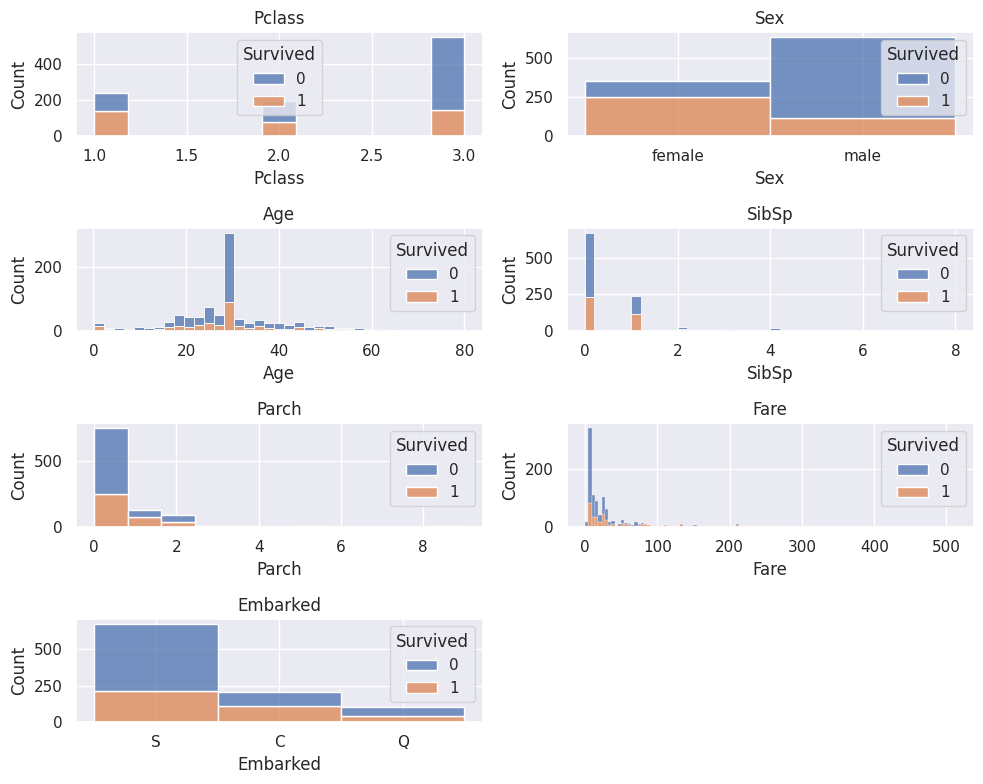

In [20]:
affiche_histogrammes(Xcol, df_train_imp, bins=None)

#### Ajout de nouvelles caractéristiques

Nous allons créer de nouvelles caractéristiques pouvant aider le classificateur à mieux départager les victimes des survivants du naufrage.

In [21]:
def add_features(df):
    df = df.copy()

    # 1. Taille de la famille
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

    # 2. Tarif par personne
    df["FarePerPerson"] = df["Fare"] / df["FamilySize"]

    # 3. Indicateur enfant
    df["IsChild"] = (df["Age"] < 16).astype(int)

    return df

In [22]:
df_train_imp = add_features(df_train_imp)
df_test_imp = add_features(df_test_imp)

In [23]:
Xcol = df_train_imp.drop(['Survived'], axis=1).columns.to_list()
Ycol = 'Survived'

On remarque que l'histogramme de la variable *Age* dans l'ensemble d'entraînement présente un pic près de la valeur d'imputation de 28 ans. Les histogrammes des autres variables ont peu changé dans les deux ensembles.

#### Détection et traitement des valeurs aberrantes

<p>&nbsp;</p>
<div align="center">
    <img src= "images/fish-outlier.png"  width="300" />
</div>
<p>&nbsp;</p>

La méthode du facteur de valeur aberrante locale (LOF) est utilisée pour identifier les valeurs aberrantes. On n'utilise pas les valeurs catégoriques ici. Les autres caractéristiques X doivent être normalisées.

Puisque les ensembles d'entraînement et de test ont des distributions similaires de données, on peut les combiner afin de déterminer un valeur seuil permettant de détecter les valeurs aberrantes. Les deux ensembles restent séparées dans les sections suivantes. 

Calcul des LOF sur train + test

In [24]:
def compute_lof_values(df_train, df_test, num_cols):
    # Combinaison des deux ensembles
    df_combined = pd.concat([df_train, df_test], ignore_index=True)

    # Normalisation robuste
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(df_combined[num_cols])

    # Calcul du nombre optimal de voisins
    n = int(np.sqrt(X_scaled.shape[0]))
    
    # Calcul des scores de LOF
    lof = LocalOutlierFactor(n_neighbors=n)
    lof_labels = lof.fit_predict(X_scaled)
    lof_values = lof.negative_outlier_factor_

    return lof_values, df_combined

# Calcul des valeurs de LOF
num_cols = ['Age', 'SibSp', 'Parch', 'Fare', 'Pclass', 'FamilySize', 'FarePerPerson']

lof_values, df_combined = compute_lof_values(df_train_imp, df_test_imp, num_cols)

Affichage des scores LOF

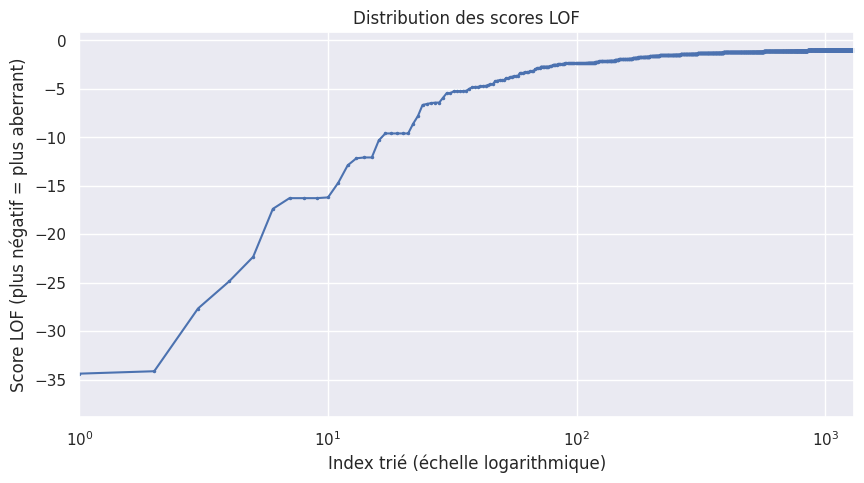

In [25]:
def plot_lof_scores(lof_values):
    sorted_scores = np.sort(lof_values)

    plt.figure(figsize=(10,5))
    plt.plot(sorted_scores, '.-', markersize=3)
    plt.xscale('log')
    plt.xlim(1, len(sorted_scores))
    plt.grid(True)
    plt.xlabel("Index trié (échelle logarithmique)")
    plt.ylabel("Score LOF (plus négatif = plus aberrant)")
    plt.title("Distribution des scores LOF")
    plt.show()

    return sorted_scores

# Affichage des valeurs de LOF
sorted_scores = plot_lof_scores(lof_values)

**Élimination des outliers dans train et test**

La figure ci-dessus montre qu'il y a très peu, voire aucune donnée aberrante. La structure en plateau apparaît à diverses échelles. Cela indique que la plupart des données aberrantes ont été éliminées de la base de données d'origine.

Nous en éliminons deux pour montrer comment procéder. Le nombre exact peut varier légèrement.

In [26]:
def remove_outliers_from_train_test(df_train, df_test, lof_values, n_outliers):
    # Tri des scores
    sorted_scores = np.sort(lof_values)

    # Seuil basé sur le nombre d'outliers
    threshold = sorted_scores[n_outliers - 1]
    print(f"Seuil LOF retenu : {threshold:.3f}")

    # Masque global
    mask_combined = lof_values > threshold

    # Reconstruction des masques pour train et test
    mask_train = mask_combined[:len(df_train)]
    mask_test  = mask_combined[len(df_train):]

    df_train_clean = df_train[mask_train].reset_index(drop=True)
    df_test_clean  = df_test[mask_test].reset_index(drop=True)

    print(f"Données train initiales : {df_train.shape[0]}")
    print(f"Données train conservées : {df_train_clean.shape[0]}")
    print(f"Outliers retirés du train : {df_train.shape[0] - df_train_clean.shape[0]}")

    print(f"Données test initiales : {df_test.shape[0]}")
    print(f"Données test conservées : {df_test_clean.shape[0]}")
    print(f"Outliers retirés du test : {df_test.shape[0] - df_test_clean.shape[0]}")

    return df_train_clean, df_test_clean, threshold

# Élimination des valeurs aberrantes.
df_train_nettoye, df_test_nettoye, threshold = remove_outliers_from_train_test(
    df_train_imp,
    df_test_imp,
    lof_values,
    n_outliers=2
)

Seuil LOF retenu : -34.388
Données train initiales : 981
Données train conservées : 980
Outliers retirés du train : 1
Données test initiales : 328
Données test conservées : 327
Outliers retirés du test : 1


Affichage de l'histogramme final des variables dans l'ensemble de données d'**entraînement** nettoyé.

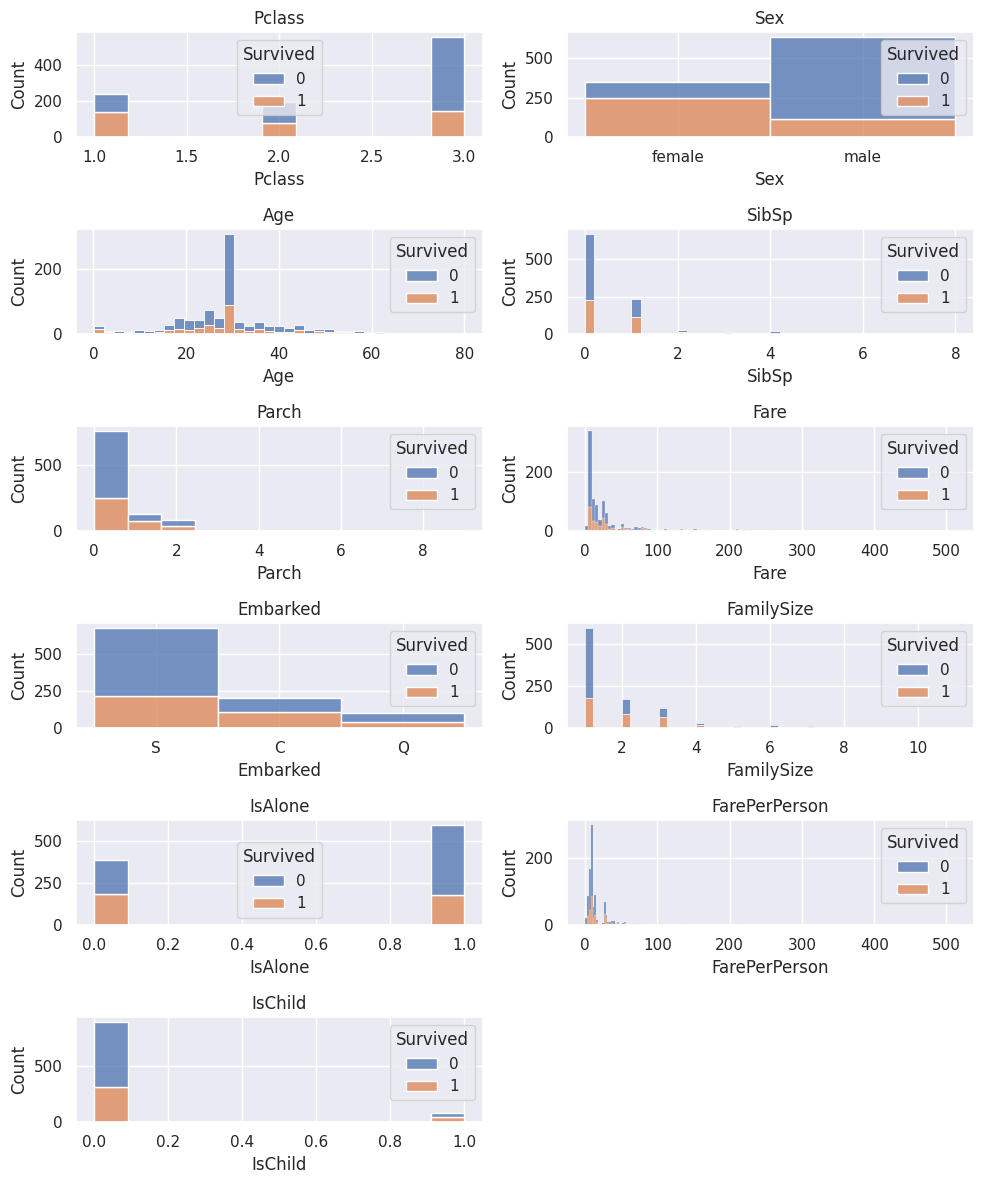

In [27]:
affiche_histogrammes(Xcol, df_train_nettoye, bins=None)

<div style="
    background-color:#fff3cd;
    border-left:6px solid #ffecb5;
    padding:20px;
    border-radius:6px;
">
<h2 style="margin-top:0; font-weight:bold;">
⚠️ ATTENTION
</h2>

<p style="font-size:1.4em; font-weight:bold;">
Voici une section fondamentale du tutoriel.
<br><br>
</p>
</div>

---
## Partie II: Classification binaire des données des passagers
---

<p>&nbsp;</p>
<div align="center">
    <img src= "images/rms_titanic__profile___1912__by_alotef-d50fyjd.png"  width="800" />
    <div>
    <font size="1.5">Image Source:https://www.deviantart.com/alotef/art/RMS-Titanic-Profile-1912-303075481/</font>
    </div>
</div>
<p>&nbsp;</p>


#### Séparation des noms de variables en entrées X et en sortie Y.

Les données sont déjà séparées et stratifiées en ensembles d'entraînement et de test.

In [28]:
target_col = "Survived"
feature_cols = df_train_nettoye.columns.drop(target_col).tolist()

print(f"Nombre de variables explicatives : {len(feature_cols)}")
print(f"Variable cible : {target_col}")

Nombre de variables explicatives : 11
Variable cible : Survived


In [29]:
X_train = df_train_nettoye[feature_cols]
y_train = df_train_nettoye[target_col]

X_test = df_test_nettoye[feature_cols]
y_test = df_test_nettoye[target_col]

print(f"Taille de X_train : {X_train.shape}")
print(f"Taille de X_test  : {X_test.shape}")
print(f"\nDistribution des survivants dans y_train :\n{y_train.value_counts(normalize=True)}")
print(f"\nDistribution des survivants dans y_test  :\n{y_test.value_counts(normalize=True)}")

Taille de X_train : (980, 11)
Taille de X_test  : (327, 11)

Distribution des survivants dans y_train :
Survived
0   0.63
1   0.37
Name: proportion, dtype: float64

Distribution des survivants dans y_test  :
Survived
0   0.59
1   0.41
Name: proportion, dtype: float64


On voit que les proportions des victimes (*Survived*=0) et des survivants (*Survived*=1) sont similaires dans les deux ensembles.

### Définition d'un pipeline de traitement des données

Dans cette section nous allons discuter de plusieurs types de prétraitement des données appliquées à des données déjà nettoyées.  Nous allons faire trois types de prétraitement

<ul>
<li>Le balancement des classes,</li>
<li>La normalisation des données,</li>
<li>Le traitement des données catégoriques.</li>
</ul>

#### Le balancement des classes


<p>&nbsp;</p>
<div align="center">
    <img src= "images/data-scale.jpeg"  width="200" />
</div>
<p>&nbsp;</p>

Il est fréquent qu'il y ait un déséquilibre entre les classes dans une base de données : la classe qui nous intéresse le plus (« classe 1 ») est souvent la plus rare. On observe alors un déséquilibre entre les classes.

En apprentissage automatique (AA), l'exactitude (*accuracy*) est une mesure de qualité en classification. Il existe plusieurs autres mesures de qualité, mais l'exactitude est la plus intuitive. Elle représente la proportion de prédictions correctes (positives et négatives) par rapport à l'ensemble des prédictions.

Que se passe-t-il dans les modèles lorsque l'entraînement est effectué sur un jeu de données déséquilibré ? Lorsqu'un modèle obtient une exactitude de 99 % avec des données déséquilibrées (99 % des instances appartiennent à la « classe 0 »), c'est parce qu'il examine les données et décide intelligemment de toujours prédire « classe 0 » pour atteindre une grande exactitude.

Est-ce si mauvais que ça ? Oui ! Pensez-y. Dans la pratique, ce sont les instances de la classe rarissime (« classe 1 ») qui nous intéressent réellement. Le classificateur précédent ne pourrait en détecter aucune dans un jeu de données ne contenant que des instances rarissimes !

### La normalisation des données

La normalisation des données est une transformation qui élimine les différents ordres de grandeur et les différentes unités des variables numériques. Ça facilite l'entraînement de beaucoup de modèles en apprentissage automatique. Ceux basés sur les arbres décisionnels (forêts aléatoires, XGBoost, AdaBoost, etc.) y sont insensibles, mais les performances des modèles linéaires (régression linéaire, régression logistique, SVM) en dépendent grandement.

<p>&nbsp;</p>
<div align="center">
    <img src= "images/normalisation.png"  width="300" />
</div>
<p>&nbsp;</p>


Dans ce tutoriel, nous allons utiliser plusieurs modèles (RandomForest, XGBoost, GradientBoosting) qui sont tous basés sur des arbres décisionnels. La normalisation des données n'est pas nécessaire ici, mais nous allons tout de même l'utiliser, car c'est une bonne habitude à prendre. Par exemple, les modèles SVM, la régression logistique et les réseaux de neurones requièrent de normaliser les données.

#### Définition du pipeline

Pour la plupart des modèles d'apprentissage automatique (régression logistique, SVM, réseaux de neurones, etc.), les variables catégoriques Sex, Embarked et Pclass doivent être converties en variables One-Hot. Toutefois, les modèles utilisés dans ce tutoriel sont basés sur des arbres décisionnels. Nous considérerons la classe des passagers *Pclass=[1, 2, 3]* comme une variable entière et non comme une catégorie.

In [30]:
num_cols = ['Age', 'SibSp', 'Parch', 'Fare', 'Pclass', 'FamilySize', 'FarePerPerson']
bin_cols = ['IsAlone', 'IsChild']
cat_cols = ['Sex', 'Embarked']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('bin', 'passthrough', bin_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
    ]
)

pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=SEED)),
    ('model', XGBClassifier())
])

#### Affichage des distributions des classes victimes et survivants.

Regardons les distributions des victimes et des survivants dans les deux ensembles de données.

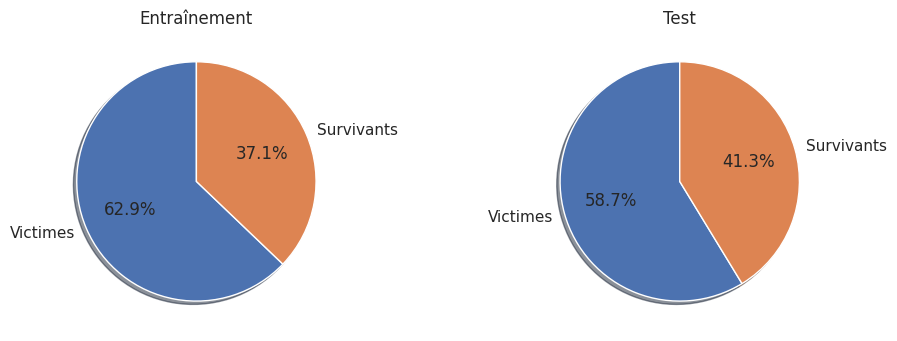

In [31]:
# Fonction d'affichage de 'Pie Charts'
def affiche (y_train, y_test):
    labels = ['Victimes', 'Survivants']
    sizes_train = [*y_train.value_counts()]
    sizes_test = [*y_test.value_counts()]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.tight_layout(pad=2.0)

    # Ensemble d'entraînement
    ax1.pie(sizes_train, labels=labels, autopct='%1.1f%%',
            shadow=True, startangle=90)
    ax1.set_title("Entraînement")
    ax1.set_aspect('equal')

    # Ensemble de test
    ax2.pie(sizes_test, labels=labels, autopct='%1.1f%%',
            shadow=True, startangle=90)
    ax2.set_title("Test")
    ax2.set_aspect('equal')

    plt.show()

affiche (y_train, y_test)

Les deux ensembles de données sont déséquilibrés. Nous allons uniquement balancer celui d'entraînement.

Pourquoi balancer l'ensemble d'entraînement? Voici comment on peut le voir : En les équilibrant, on offre au classificateur les meilleures chances possibles de bien les différencier, ce qui améliore les performances des modèles d'apprentissage automatique. On ne le fait pas toujours lorsque le débalancement est faible, mais nous allons le faire dans ce cas-ci.

Pourquoi ne pas balancer l'ensemble de test? Parce qu'on ne peut pas s'attendre à ce que les données du monde réel soient équilibrées lorsqu'on va déployer un modèle. On veut ainsi obtenir les performances réelles du modèle dans la pratique.

Montrons l'effet du balancement des classes du jeu d'entraînement avec la méthode [SMOTE](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTE.html).

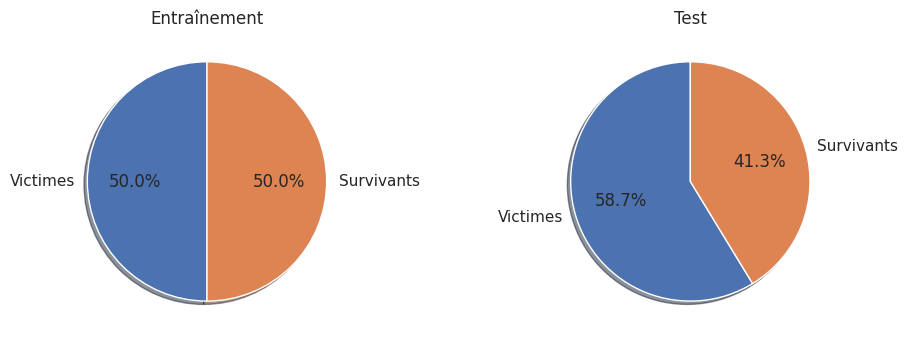

In [32]:
# 1. Prétraitement (fit_transform)
X_train_pre = pipeline.named_steps['preprocess'].fit_transform(X_train)
X_test_pre = pipeline.named_steps['preprocess'].transform(X_test)

# 2. SMOTE (fit_resample)
X_train_bal, y_train_bal = pipeline.named_steps['smote'].fit_resample(
    X_train_pre, y_train
)

# 3. Visualisation
affiche(y_train_bal, y_test)

Les classes victimes et survivants sont maintenant balancées uniquement dans l'ensemble d'entraînement.

---
### Entraînement et optimisation d'un classificateur
---

<p>&nbsp;</p>
<div align="center">
    <img src= "images/7749808022_e4e2a1271c_b.jpg"  width="400" />
</div>
<p>&nbsp;</p>

Une fois les données prétraitées, on peut passer à l'étape d'entraînement du classificateur.
Il existe plusieurs types de classificateurs. Plutôt que de choisir son modèle préféré, il est recommandé d'en entraîner plusieurs, car leurs performances peuvent varier considérablement d'une base de données à l'autre. On choisit ensuite le meilleur parmi eux. 

#### Choix des hyperparamètres (HP)

Chaque classificateur comporte son lot d'hyperparamètres à ajuster. Toutefois, le nombre d'HP ayant le plus grand impact sur les résultats est assez restreint. On en sélectionne quelques-uns pour chaque classificateur à tester. Il est souvent possible de trouver sur Internet ou en utilisant un chatbot quels sont les meilleurs paramètres à utiliser pour un modèle donné.

Quelle méthode d'optimisation utiliser? La figure suivante en compare trois
<ul>
<li>sur grille,</li>
<li>aléatoire, </li>
<li>bayésienne.</li>
</ul>  

La figure montre, en couleur, la fonction à optimiser. Dans ce cas, on cherche la position $(x_1, x_2)$ du minimum. Les points noirs indiquent les combinaisons d'hyperparamètres utilisées. Contrairement aux deux premières méthodes, la méthode bayésienne apprend de ses essais et erreurs. Elle modélise la fonction à optimiser et suggère une nouvelle combinaison d'HP proche de l'optimum recherché. C'est ce que montre la figure. Notez les positions des essais successifs dans le dernier panneau. Elles se rapprochent graduellement du minimum global, situé en bas à gauche. Les performances s'améliorent ainsi au fil des essais.


<p>&nbsp;</p>
<div align="center">
    <img src= "images/heatmap.001-min.jpeg"  width="500" />
</div>
<p>&nbsp;</p>

Notez que la recherche Bayésienne n'est pas toujours la meilleure si le nombre d'essais est faible. De plus, elle prend plus de temps à effectuer. Par contre lorsqu'il y a beaucoup de données à traiter, par exemple 100 000 plutôt que 1000, cette approche est préférable aux approches sur grille et aléatoire. Le temps d'entraînement d'un modèle devient alors plus long que le temps requis pour déterminer le nouvel ensemble d'HP à tester.

Pour une comparaison plus détaillée des diverses approches, jetez un coup d'oeil à cet [article](https://arxiv.org/pdf/2104.10201.pdf).

Définissons une fonction qui entraîne un modèle avec la méthode bayésienne. On utilise la populaire librairie Optuna pour optimiser les hyperparamètres. Nous allons maximiser le score F1 plutôt que l'exactitude.

In [33]:
from imblearn.pipeline import Pipeline as ImbPipeline
optuna.logging.set_verbosity(optuna.logging.WARNING)

def optuna_optimize_pipeline(
    model_class, params, preprocessor, X_train, y_train,
    n_trials=50, base_params=None, seed=SEED
):
    if base_params is None:
        base_params = {}

    # CV stratifiée
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    def objective(trial):
        trial_params = {}

        # Hyperparamètres Optuna
        for name, spec in params.items():
            ptype = spec[0]

            if ptype == "int":
                trial_params[name] = trial.suggest_int(name, spec[1], spec[2])

            elif ptype == "float":
                trial_params[name] = trial.suggest_float(name, spec[1], spec[2])

            elif ptype == "loguniform":
                trial_params[name] = trial.suggest_float(name, spec[1], spec[2], log=True)

            elif ptype == "categorical":
                trial_params[name] = trial.suggest_categorical(name, spec[1])

        # Fusion des paramètres
        full_params = {**base_params, **trial_params}

        # Pipeline complet
        pipe = ImbPipeline(steps=[
            ('preprocess', preprocessor),
            ('smote', SMOTE(random_state=seed)),
            ('model', model_class(**full_params))
        ])

        # Score CV
        scores = cross_val_score(
            pipe, X_train, y_train,
            cv=cv,
            scoring="f1",
            n_jobs=-1
        )

        return scores.mean()

    # Étude Optuna
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=seed),
        pruner=optuna.pruners.MedianPruner()
    )

    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    # Meilleurs paramètres
    best_params = {**base_params, **study.best_params}

    # Pipeline final entraîné sur tout le train
    best_pipeline = ImbPipeline(steps=[
        ('preprocess', preprocessor),
        ('smote', SMOTE(random_state=seed)),
        ('model', model_class(**best_params))
    ])

    best_pipeline.fit(X_train, y_train)

    return study.best_value, study.best_params, best_pipeline

####  Espaces de recherche des hyperparamètres

Définissons l'espace de recherche des hyperparamètres pour chacun des trois modèles utilisés. Pour chacun d'entre eux, on peut demander à un chatbot tel que Copilot de mentionner les hyperparamètres les plus optimisés avec Optuna, ainsi que la plage des valeurs possibles en fonction de la dimension des données d'entraînement. Par exemple, df_train_nettoye a une taille de (980, 8) et les caractéristiques sont normalisées.

In [34]:
models_to_optimize = [
    {
        "name": "RandomForest",
        "cls": RandomForestClassifier,
        "params": {
            "n_estimators": ("int", 50, 300),
            "max_depth": ("int", 2, 10),
            "max_features": ("categorical", ["sqrt", "log2"]),
            "min_samples_split": ("int", 2, 20),
            "min_samples_leaf": ("int", 1, 10)
        },
        "base_params": {
            "random_state": SEED
        }
    },

    {
        "name": "GradientBoosting",
        "cls": GradientBoostingClassifier,
        "params": {
            "n_estimators": ("int", 50, 300),
            "learning_rate": ("loguniform", 0.01, 0.3),
            "max_depth": ("int", 2, 6),
            "subsample": ("float", 0.5, 1.0),
            "max_features": ("categorical", ["sqrt", "log2"])
        },
        "base_params": {
            "random_state": SEED,
            "verbose": 0         
        }
    },

    {
        "name": "XGBoost",
        "cls": XGBClassifier,
        "params": {
            "learning_rate": ("loguniform", 0.01, 0.15),
            "max_depth": ("int", 2, 5),
            "min_child_weight": ("int", 1, 8),
            "subsample": ("float", 0.5, 0.9),
            "colsample_bytree": ("float", 0.5, 0.9),
            "gamma": ("float", 0.0, 3.0),
            "n_estimators": ("int", 150, 400),
            "reg_lambda": ("loguniform", 1e-2, 10),
            "reg_alpha": ("loguniform", 1e-3, 1),
        },
        "base_params": {
            "tree_method": "hist",
            "random_state": SEED,
            "eval_metric": "logloss",
            "objective": "binary:logistic",
            "verbosity": 0
        }
    }
]

Entraînement des trois modèles et sauvegarde des résultats pour comparaison, afin de sélectionner le plus performant. Cette étape est la plus longue du tutoriel. On utilise *n_trials = 50*. Les résultats sont meilleurs avec *n_trials = 500*, mais les calculs sont plus longs.

In [35]:
results = {}

for entry in models_to_optimize:
    print(f"\n=== Optimisation : {entry['name']} ===")

    score, best_params, best_pipeline = optuna_optimize_pipeline(
        model_class=entry["cls"],
        params=entry["params"],
        preprocessor=preprocessor,
        X_train=X_train,
        y_train=y_train,
        n_trials=50,
        base_params=entry["base_params"]
    )

    results[entry["name"]] = {
        "score": score,
        "best_params": best_params,
        "best_pipeline": best_pipeline
    }

    print(f"{entry['name']} - Score : {score}")
    print(f"{entry['name']} - Meilleurs paramètres : {best_params}")


=== Optimisation : RandomForest ===


  0%|          | 0/50 [00:00<?, ?it/s]

RandomForest - Score : 0.7279372405911192
RandomForest - Meilleurs paramètres : {'n_estimators': 73, 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_split': 6, 'min_samples_leaf': 8}

=== Optimisation : GradientBoosting ===


  0%|          | 0/50 [00:00<?, ?it/s]

GradientBoosting - Score : 0.7246333764058736
GradientBoosting - Meilleurs paramètres : {'n_estimators': 96, 'learning_rate': 0.015847838364192738, 'max_depth': 4, 'subsample': 0.8152067583346994, 'max_features': 'sqrt'}

=== Optimisation : XGBoost ===


  0%|          | 0/50 [00:00<?, ?it/s]

XGBoost - Score : 0.7305243448263479
XGBoost - Meilleurs paramètres : {'learning_rate': 0.024896521901460526, 'max_depth': 3, 'min_child_weight': 4, 'subsample': 0.6733771758289397, 'colsample_bytree': 0.8523239502955888, 'gamma': 1.7772702371431879, 'n_estimators': 255, 'reg_lambda': 0.8485740653342217, 'reg_alpha': 0.17820047458281987}


Sélection du meilleur modèle

In [36]:
best_model_name = max(results, key=lambda m: results[m]["score"])
best_pipeline = results[best_model_name]["best_pipeline"]

print("\n=== Meilleur modèle global ===")
print("Modèle :", best_model_name)


=== Meilleur modèle global ===
Modèle : XGBoost


#### Affichage du rapport de classification pour le modèle optimal

<p>&nbsp;</p>
<div align="center">
    <img src= "images/human-character.jpeg"  width="300" />
</div>
<p>&nbsp;</p>

Le rapport de classification présente les scores d'exactitude (*accuracy*), de précision, de rappel (*recall*), et de F1 pour les classes Victimes (« classe 0 ») et Survivants (« classe 1 »).

In [37]:
y_pred = best_pipeline.predict(X_test)

print(classification_report(
    y_test,
    y_pred,
    target_names=['Victimes', 'Survivants']
))

              precision    recall  f1-score   support

    Victimes       0.83      0.85      0.84       192
  Survivants       0.78      0.76      0.77       135

    accuracy                           0.81       327
   macro avg       0.81      0.80      0.81       327
weighted avg       0.81      0.81      0.81       327



Intéressons-nous à la ligne qui montre les résultats pour les passagers survivants. On observe ceci

<ul>
<li>une précision de 78 % signifie que lorsque le modèle prédit qu'un passager va survivre, il a raison 78 % du temps,</li>
<li>un rappel (*recall*) de 75 % signifie que le modèle est capable d'identifier 75 % des passagers qui vont survivre.</li>
</ul>

Question: En supposant que vous ayez eu accès à cette information avant d'embarquer sur le Titanic et que le modèle ait prédit que vous alliez survivre, quelle métrique aurait été la plus importante à vos yeux; l'exactitude, la précision ou le rappel? 

Pensez-y:
<ul>
<li>l'exactitude indique simplement que le modèle fait de bonnes prédictions (survivant ou non) 81 % du temps,</li>
<li>le rappel indique que le modèle va être capable d'identifier 75 % des survivants,</li>
<li>la précision indique qu'il fait de bonnes prédictions de survie seulement 78 % du temps.</li>
</ul>

Réponse: C'est la précision, car elle vous dit vos chances de survivre!
### Faire une prédiction pour un nouveau passager
---

Beaucoup d'exemples sur le web montrent comment optimiser les performances d'un classificateur, ou de plusieurs en même temps, afin de sélectionner le meilleur d'entre eux. Toutefois, ils ne montrent presque jamais comment utiliser ensuite ce classificateur sur de nouvelles données.

<p>&nbsp;</p>
<div align="center">
    <img src= "images/p04zr257.jpg"  width="400" />
    <div>
    <font size="1.5">Image Source: https://www.bbc.com/future/article/20170411-the-monster-ships-that-changed-how-we-travel//</font>
    </div>
</div>
<p>&nbsp;</p>

Nous allons prédire la probabilité de survie d'une passagère de 29 ans voyageant en seconde classe avec son mari, sans parent ni enfant, et qui a embarqué au port de Southampton, en Angleterre. On suppose que le prix de son billet était le prix moyen, soit 31 Pounds.

**Remarque**: testez différents scénarios de passagers afin de déterminer les éventuelles issues.

#### Création du dataframe correspondant à la passagère

In [38]:
# Profil d'un passager
df_passager = pd.DataFrame({    
    'Pclass' : [2],     # Billet de seconde classe
    'Age' : [29],       # Âge moyen
    'SibSp' : [1],      # Voyageant avec un conjoint
    'Parch' : [0],      # Sans enfants, ni parents
    'Fare' : [31],      # Prix moyen
    'Sex' : ['female'], 
    'Embarked' : ['S']
    }
)

# Ajout de caractéristiques
df_passager_a = add_features(df_passager)

# Affichage des données de la passagère 
df_passager_a

,Pclass,Age,SibSp,Parch,Fare,Sex,Embarked,FamilySize,IsAlone,FarePerPerson,IsChild
0,2,29,1,0,31,female,S,2,0,15.50,0


Calcul de la probabilité de survie. Elle est calculée en utilisant le pipeline final de traitement des données.

In [39]:
proba_pipeline = best_pipeline.predict_proba(df_passager_a)[0, 1]
print(f"Probabilité estimée de survie : {100*proba_pipeline:.0f} %")

Probabilité estimée de survie : 88 %


<div style="
    background-color:#fff3cd;
    border-left:6px solid #ffecb5;
    padding:20px;
    border-radius:6px;
">
<h2 style="margin-top:0; font-weight:bold;">
⚠️ ATTENTION
</h2>

<p style="font-size:1.4em; font-weight:bold;">
Voici une section fondamentale du tutoriel.
<br><br>
</p>
</div>

---
## Partie III: Interprétabilité des résultats de classification de survie au naufrage.
---

<p>&nbsp;</p>
<div align="center">
    <img src= "images/titanic_sinking_by_admiral_kevin-d882cfj.jpg"  width="400" />
    <div>
    <font size="1.5">Image Source:https://www.deviantart.com/admiral-kevin/art/Titanic-sinking-497275759/</font>
    </div>
</div>
<p>&nbsp;</p>


Dans cette partie, nous verrons comment interpréter les prédictions d'un classificateur permettant d'identifier les sujets qui vont survivre au naufrage du Titanic.

Maintenant qu'on a un classificateur, que peut-il nous apprendre sur les variables importantes?

Les données ont été nettoyées dans la première partie. Elles ont ensuite servi à entraîner un classificateur dans la seconde partie. Nous allons maintenant utiliser une méthode d'interprétabilité pour mieux comprendre les prédictions et voir comment elles dépendent des caractéristiques des sujets étudiés (âge, sexe, etc.).

#### La méthode de Shapley

Les valeurs SHAP (*SHapley Additive exPlanations*) représentent la contribution (positive ou négative) de chaque variable à la prédiction d'un modèle. La somme de toutes les contributions permet de calculer la réponse $y$ du modèle.

Dans le cas du naufrage du Titanic, les valeurs positives augmentent les chances de survie des passagers et les valeurs négatives les diminuent.

### Préparation des données pour cette partie

#### Prétraitement des données (encodées + normalisées)

In [40]:
# Prétraitement identique à celui du pipeline
X_test_pre = preprocessor.transform(X_test)

#### Noms des colonnes après OneHotEncoder.

Il faut connaître les noms des colonnes transformées.

In [41]:
# --- 3. Extraction des noms de colonnes EXACTS ---
def get_feature_names_from_preprocessor(preprocessor):
    feature_names = []

    # 1. Numériques (StandardScaler)
    if 'num' in preprocessor.named_transformers_:
        num_features = preprocessor.named_transformers_['num'].feature_names_in_
        feature_names.extend(num_features)

    # 2. Binaires (passthrough)
    #    Ici, pas de .feature_names_in_ car 'passthrough' n'est pas un transformateur sklearn
    for name, trans, cols in preprocessor.transformers_:
        if name == 'bin':
            feature_names.extend(cols)

    # 3. Catégorielles (OneHotEncoder)
    if 'cat' in preprocessor.named_transformers_:
        ohe = preprocessor.named_transformers_['cat']
        ohe_features = ohe.get_feature_names_out(ohe.feature_names_in_)
        feature_names.extend(ohe_features)

    return feature_names

feature_names = get_feature_names_from_preprocessor(preprocessor)

### Calcul des valeurs SHAP pour le modèle optimal

On va calculer les valeurs SHAP à partir du modèle final (dans le pipeline) après entraînement.

In [42]:
# On récupère le modèle entraîné
model = best_pipeline.named_steps['model']

# On crée l'explainer SHAP spécifique aux modèles basés sur des arbres de décision.
# Cette étape est parfois longue à effectuer lorsqu'il y a beaucoup de données et de caractéristiques.
explainer = shap.TreeExplainer(model)

# Calcul des valeurs SHAP pour toutes les observations prétraitées
shap_values = explainer.shap_values(X_test_pre)

print("SHAP values shape :", np.array(shap_values).shape)

ValueError: could not convert string to float: '[5E-1]'

N.B. Les données sont maintenant en 12 dimensions.

Affichons maintenant l'importance de chaque variable, en ordre décroissant.

In [ ]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_pre, feature_names=feature_names, plot_type="bar")
plt.show()

Les trois facteurs ayant le plus contribué à la probabilité de survie au naufrage étaient les suivants:
<ul>
<li>le sexe d'un passager,</li>
<li>la classe dans laquelle il a voyagé,</li>
<li>son âge.</li>
</ul>    

Affichons maintenant le *Beeswarm Plot* qui montre la distribution et la direction des effets.

In [ ]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_pre, feature_names=feature_names)
plt.show()

La figure semble intimidante et complexe au premier abord, mais comme on dit souvent, *la familiarité vient avec l'usage*.

Ce qu'il faut retenir:
<ul>
<li>L'échelle de couleurs correspond à la valeur numérique de chaque variable, faible (bleu) et forte (rouge).</li>

<li>Plus une variable a une valeur SHAP positive, plus elle augmente la probabilité de survie. </li>

<li>Plus une variable a une valeur SHAP négative, plus elle diminue la probabilité de survie.</li>

<li>Sur chaque ligne, il y a autant de points que de sujets dans la base de données.</li>
</ul>

Regardons la variable *Sex_Male*. Les points bleus (*Sex_Male=0*) correspondent à des femmes. Elles ont des valeurs SHAP positives et donc de bonnes chances de survivre au naufrage. C'est l'inverse pour les hommes (*Sex_Male=1*, points rouges).

Notez que la probabilité de survie diminuait lorsque la classe des billets des passagers augmentait. Ainsi, les passagers de première classe avaient de meilleures chances de survie (points bleus et $SHAP>0$) que ceux en troisième classe (points rouges et $SHAP<0$). 

Voilà comment expliquer cette étrange figure.

### Faire une prédiction pour un nouveau passager

Dans la seconde partie, nous avons vu comment prédire la probabilité de survie d'une passagère. Le modèle avait prédit une probabilité de 81 %, sans toutefois fournir d'explications. Nous aimerions savoir quelles variables ont déterminé ce résultat. L'analyse précédente ne permettait pas d'y répondre.

Utilisons maintenant l'approche descriptive de Shapley. 

In [ ]:
# Prétraitement des données
X_sujet_pre = best_pipeline.named_steps['preprocess'].transform(df_passager_a)

# Génération de l'Explainer
model = best_pipeline.named_steps['model']
explainer = shap.Explainer(model, feature_names=feature_names)

# Calcul des valeurs SHAP
shap_sujet = explainer(X_sujet_pre)

Calculons la probabilité de survie selon la méthode de Shapley.

In [ ]:
# 1. Valeur de base (scalaire)
base_value = float(shap_sujet.base_values)

# 2. Somme des SHAP values (scalaire)
shap_sum = float(shap_sujet.values.sum())

# 3. Logit
logit_shap = base_value + shap_sum

# 4. Probabilité
proba_shap = 1 / (1 + np.exp(-logit_shap))

print(f"Probabilité via SHAP : {100*proba_shap:.0f} %")

On obtient le même résultat qu'auparavant, mais cette approche présente une plus-value. On peut maintenant examiner quelles caractéristiques de la passagère ont déterminé sa probabilité de survie. C'est ça, l'explicabilité !

Affichons le diagramme « Waterfall » qui montre la contribution de chaque variable à la probabilité de survie.

In [ ]:
# Affichage du diagramme Waterfall
shap.plots.waterfall(shap_sujet[0], max_display=20)

<p>&nbsp;</p>
<div align="center">
    <img src= "images/inspector-with-magnifying-glass.jpeg"  width="150" />
</div>
<p>&nbsp;</p>

Les principaux facteurs qui ont augmenté ses chances de survie (en rouge) sont le sexe et le prix et la classe des billets. Notez que les valeurs affichées à côté des barres sont les valeurs transformées après l'étape de prétraitement. 

### Comment les caractéristiques individuelles influencent-elles la probabilité de survie ?

Il est plus intéressant encore d'afficher la relation entre les valeurs SHAP et une variable donnée. Cela met en évidence la relation souvent complexe (i.e. nonlinéaire) entre la variable et la réponse que l'on veut prédire. 

Préparons d'abord les données pour les mettre sous une forme utile au type de visualisation que l'on recherche.

#### Affichage de l'effet des principales caractéristiques sur la probabilité de survie au naufrage.

On reconstruit X_test_raw_display avec les valeurs brutes

In [ ]:
X_test_raw_display = []

for idx, row in X_test.iterrows():
    raw_row = []
    for col in feature_names:
        if col in X_test.columns:
            # colonnes numériques ou binaires
            raw_row.append(row[col])
        elif col.startswith("Sex_"):
            raw_row.append(1 if row["Sex"] == col.split("_")[1] else 0)
        elif col.startswith("Embarked_"):
            raw_row.append(1 if row["Embarked"] == col.split("_")[1] else 0)
        else:
            raw_row.append(None)
    X_test_raw_display.append(raw_row)

X_test_raw_display = np.array(X_test_raw_display, dtype=float)

Définissons une fonction d'affichage permettant de montrer comment les variables de Shapley dépendent des caractéristiques des passagers. La figure représentera, en abscisse, la caractéristique d'intérêt et, en ordonnée, les valeurs SHAP correspondantes. Elle affichera également l'interaction avec le sexe de chaque passager. Les hommes seront représentés par des points rouges et les femmes par des points bleus. 

Clé pour bien comprendre les résultats: lorsque $SHAP<0$ les chances de survie diminuent et elles augmentent lorsque $SHAP>0$.

In [ ]:
def affiche_influence_des_variables(var, shap_values, X_test_raw_display):
    print(f"\n=== SHAP dependence plot pour : {var} ===")
    shap.dependence_plot(
        var,
        shap_values,
        X_test_raw_display,   # <-- valeurs brutes !
        feature_names=feature_names,
        interaction_index='Sex_male'
    )

Affichons maintenant les courbes les plus intéressantes.

In [ ]:
affiche_influence_des_variables('Sex_male', shap_values, X_test_raw_display)

Cette figure montre clairement que la probabilité de survie était moindre chez les hommes. Le code moral « Les femmes et les enfants d’abord » est né au $XIX^{e}$ siècle et est devenu célèbre après quelques naufrages emblématiques. L'effet est ici manifeste !

In [ ]:
affiche_influence_des_variables('IsChild', shap_values, X_test_raw_display)

Cette figure montre que les enfants avaient plus de chances de survivre. « Les femmes et les enfants d’abord »

In [ ]:
affiche_influence_des_variables('Age', shap_values, X_test_raw_display)

Voici probablement la figure la plus intéressante. On peut faire les observations suivantes:

<ul>
<li>Les jeunes enfants (<10 ans) avaient d'excellentes chances de survivre;</li>
<li>Les chances de survie diminuaient pour les enfants de plus de 10 ans;</li>
<li>Il y a un pic entre 22 et 27 ans environ, correspondant aux parents des jeunes enfants qui les accompagnaient dans les canots de sauvetage;</li>
<li>Au-delà de 30 ans, moins d'hommes que de femmes survivaient;</li>
<li>Au-delà de 55 ans (une personne âgée à l'époque) les chances de survie diminuaient rapidement.</li>
</ul>   

In [ ]:
affiche_influence_des_variables('Pclass', shap_values, X_test_raw_display)

Cette figure montre clairement que la probabilité de survie diminuait en fonction de la classe des billets. En tenant compte du prix des billets, cela correspond *grosso modo* à la classe sociale des passagers. Notez toutefois qu'en troisième classe, les hommes avaient légèrement plus de chances de survivre que les femmes, bien que les passagers de cette classe étaient très désavantagés par rapport aux deux autres.

In [ ]:
affiche_influence_des_variables('FamilySize', shap_values, X_test_raw_display)

Cette figure montre que les membres de familles nombreuses avaient moins de chances de survie. Il s'agissait souvent de familles voyageant en troisième classe pour des raisons économiques. 

Nos résultats confirment les observations faites par des commissions d'enquête en Europe et aux États-Unis. Celles-ci se basaient sur l'analyse statistique des données inscrites dans les registres des passagers compilés à Cherbourg, à Queenstown et à Southampton, ainsi que sur les noms des survivants et des victimes recueillis au Canada et aux États-Unis. Ces données ont permis de reconstituer le scénario du naufrage du Titanic.

---
## Partie IV : Conclusion
---

<p>&nbsp;</p>
<div align="center">
    <img src= "images/union-fait-la-force.jpeg"  width="500" />
</div>
<p>&nbsp;</p>

Dans ce tutoriel, nous avons vu comment utiliser l'apprentissage automatique pour analyser des données contenues dans un fichier CSV.
Il aurait également été possible d'extraire les mêmes données d'un fichier Excel.

Nous avons vu qu'il y avait beaucoup d'étapes, dont l'ordre d'exécution est également important.

Dans un projet typique d'apprentissage automatique, le prétraitement des données peut représenter plus de 50 % des efforts investis ! L'entraînement et la sélection du meilleur modèle de classification parmi plusieurs sont généralement plus rapides.

L'analyse des résultats, et plus particulièrement leur interprétabilité, permet de mieux comprendre le phénomène étudié, que l'on soit médecin, ingénieur, pédagogue, etc. Dans le cas du diabète, le phénomène est vraiment non linéaire ; les méthodes statistiques standard n'auraient pas permis d'exposer autant de détails.

Au fil des ans, la partie la plus intéressante d'un projet est devenue l'utilisation des valeurs SHAP pour effectuer une analyse de groupe. On applique des plongements de données (*data embeddings*) aux valeurs SHAP, puis on effectue des regroupements de données (*cluster analysis*) pour identifier des groupes naturels de données. L'analyse des variables correspondantes permet de déterminer la nature de chaque groupe et leurs caractéristiques. Cette technique est utilisée pour l'analyse de marché, l'identification de différentes variantes d'une maladie (comme le diabète), etc.


### Remarques finales

Les résultats présentés dans ce tutoriel ne sont valables que pour la base de données utilisée. De plus, l'ordre précis des variables importantes peut légèrement varier en fonction du type de prétraitement ou de classificateur utilisé.

Le tutoriel étant déjà assez long, nous nous sommes limités à l'essentiel. 

**Il est important de mentionner que le même type d'analyse aurait pu être appliqué dans le cadre d'un projet en psychologie, en pédagogie, en astronomie, etc. en autant que les données soit disponibles sous forme tabulaire.**